In [6]:
import os

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [7]:
df = pd.read_csv("data/dataset.csv")

In [8]:
df["clean_text"] = df["clean_text"].fillna("")
X = df["clean_text"]
y_style = df["style"]
y_tone = df["tone"]

X_train_style, X_test_style, y_train_style, y_test_style = train_test_split(
    X, y_style, test_size=0.2, random_state=42, stratify=y_style
)

X_train_tone, X_test_tone, y_train_tone, y_test_tone = train_test_split(
    X, y_tone, test_size=0.2, random_state=42, stratify=y_tone
)

pipeline = Pipeline(
    [("tfidf", TfidfVectorizer()), ("classifier", LinearSVC())]
)

param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "classifier__C": [0.1, 1, 10],
}


Tuning STYLE model...

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time=   0.2s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time=   0.2s
[CV] END classi

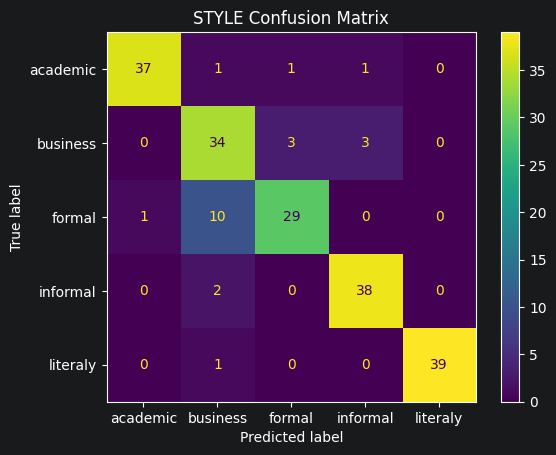


Saved style_model.joblib


In [9]:
print("\nTuning STYLE model...\n")

grid_style = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    n_jobs=-1,
)

grid_style.fit(X_train_style, y_train_style)
best_style_model = grid_style.best_estimator_
print(f"\nCross-validation Style F1 (weighted): {grid_style.best_score_:.4f}")

print("Best STYLE params:")
print(grid_style.best_params_)

style_predictions = best_style_model.predict(X_test_style)
style_f1 = f1_score(y_test_style, style_predictions, average="weighted")
print(f"\nSTYLE F1-score: {style_f1:.4f}")

print("\nSTYLE Classification Report:\n")
print(classification_report(y_test_style, style_predictions))

style_cm = confusion_matrix(y_test_style, style_predictions)
disp_style = ConfusionMatrixDisplay(
    confusion_matrix=style_cm, display_labels=best_style_model.classes_
)
disp_style.plot()
plt.title("STYLE Confusion Matrix")
plt.show()

os.makedirs("saving", exist_ok=True)

with open("saving/style_model.joblib", "wb") as f:
    joblib.dump(best_style_model, f)
print("\nSaved style_model.joblib")


Tuning TONE model...

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time=   0.2s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time=   0.2s
[CV] END classifier__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time=   0.2s
[CV] END classif

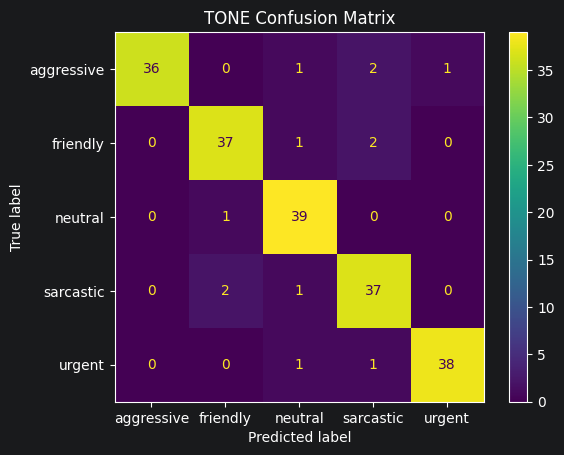


Saved tone_model.joblib


In [10]:
print("\nTuning TONE model...\n")

grid_tone = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    n_jobs=-1,
)

grid_tone.fit(X_train_tone, y_train_tone)
best_tone_model = grid_tone.best_estimator_
print(f"\nCross-validation Tone F1 (weighted): {grid_tone.best_score_:.4f}")

print("Best TONE params:")
print(grid_tone.best_params_)

tone_predictions = best_tone_model.predict(X_test_tone)
tone_f1 = f1_score(y_test_tone, tone_predictions, average="weighted")
print(f"\nTONE F1-score: {tone_f1:.4f}")

print("\nTONE Classification Report:\n")
print(classification_report(y_test_tone, tone_predictions))

tone_cm = confusion_matrix(y_test_tone, tone_predictions)
disp_tone = ConfusionMatrixDisplay(
    confusion_matrix=tone_cm, display_labels=best_tone_model.classes_
)
disp_tone.plot()
plt.title("TONE Confusion Matrix")
plt.show()

os.makedirs("saving", exist_ok=True)

with open("saving/tone_model.joblib", "wb") as f:
    joblib.dump(best_tone_model, f)
print("\nSaved tone_model.joblib")